# Checkpoint 1 - Pseudo-Labeling & Feature Engineering
## Risk Score (0-100) dari Chicago Crimes

**Grup 01 - SISTECH 2026 MLOps (RISTEK Fasilkom UI)**
Ira Arianti Alawiah · Adinda Sekaring Wana

---

Notebook ini mengubah data mentah **Chicago Crimes** menjadi dataset **fitur + label
Risk Score (0-100)** per unit analisis **(sel grid × hari × jam)** - skor yang
menggambarkan tingkat risiko sebuah lokasi pada waktu tertentu berdasarkan pola
kejahatan historis. Dataset hasilnya menjadi fondasi untuk model dan REST API di
Checkpoint 2.

**Alur:**
1. Setup & muat data
2. Pembersihan & kanonikalisasi taksonomi
3. EDA seperlunya - yang memandu keputusan desain
4. Feature engineering (spasial & temporal)
5. Pseudo-labeling: severity → temporal decay → agregasi spasial → normalisasi
6. Uji akal sehat terhadap empat skenario dokumen soal
7. Dataset akhir, limitasi, dan disclaimer etis

**Catatan proses.** Notebook ini adalah hasil **konsolidasi dua pendekatan** yang
dikerjakan terpisah oleh Ira dan Dinda. Perbandingan lengkap kedua pendekatan ada di
`PERBANDINGAN.md`; ringkasnya, unit analisis dan inti pseudo-labeling mengikuti
pendekatan Ira (punya resolusi jam - sesuai kebutuhan rekomendasi rute aman),
sementara disiplin pembersihan taksonomi dan pemisahan kolom pembentuk label diadopsi
dari pendekatan Dinda. Dua parameter (half-life dan bandwidth spasial) serta metode
normalisasi **direvisi** berdasarkan uji akal sehat di Bagian 6 - perbaikan atas
kedua versi awal.

## 1. Setup

Seluruh logika inti (grid-binning, fitur waktu, severity, decay, kernel spasial,
normalisasi) berada di **`features.py`**, bukan di notebook ini. Notebook hanya
memanggilnya.

Ini keputusan desain yang penting untuk masa depan proyek: fungsi yang sama akan
dipakai REST API di CP2. Kalau training dan serving memakai logika yang berbeda
sedikit saja - misalnya pembulatan grid beda satu desimal - API akan mengeluarkan
skor yang ngawur padahal modelnya benar.

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.getcwd())          # supaya features.py di folder yang sama terbaca
import features as F

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
np.random.seed(42)

print("Parameter desain yang dipakai (semua terpusat di features.py):")
print(f"  ukuran grid          : {F.GRID_DECIMALS} desimal  (~1.1 km per sel)")
print(f"  half-life temporal   : {F.HALF_LIFE_DAYS:.0f} hari")
print(f"  sigma kernel spasial : {F.SIGMA_KM} km  (radius potong {F.CUTOFF_KM} km)")
print(f"  jangkar skor 100     : persentil {F.CLIP_PERCENTILE:.0%} dari risk_raw")
print(f"  eksponen kurva skor  : {F.SCORE_EXPONENT}")

Parameter desain yang dipakai (semua terpusat di features.py):
  ukuran grid          : 2 desimal  (~1.1 km per sel)
  half-life temporal   : 365 hari
  sigma kernel spasial : 0.7 km  (radius potong 3.0 km)
  jangkar skor 100     : persentil 99% dari risk_raw
  eksponen kurva skor  : 0.5


## 2. Muat Dataset

Dataset **Chicago Crimes** (2001-sekarang, ~8,5 juta baris). Hanya kolom yang
diperlukan yang dibaca agar hemat memori.

Tiga karakteristik pencatatan dari dokumentasi resmi Chicago Data Portal yang relevan
untuk desain di bawah:

1. **Lokasi dianonimkan ke level blok** demi privasi korban - koordinat mewakili blok
   (~100-150 m), bukan titik persis. Grid ~1,1 km yang dipakai nanti jauh di atas
   resolusi ini, jadi agregasi kita tidak membuang informasi spasial yang nyata.
2. **Waktu kejadian kerap estimasi** ("best estimate") - granularitas per jam adalah
   resolusi temporal paling halus yang masih jujur terhadap kualitas data.
3. **Data adalah kejahatan yang dilaporkan**, klasifikasi awalnya masih bisa direvisi.

In [2]:
# Notebook mencari file lokal dulu; kalau tidak ada, unduh dari sumber dokumen hands-on.
DATA_PATH = os.environ.get("CHICAGO_CSV", "chicago_crimes.csv")
FILE_ID   = "12K13Az7ynV3ZVimSARImgggnbDbVqjk_"

if not os.path.exists(DATA_PATH):
    import gdown
    gdown.download(id=FILE_ID, output=DATA_PATH, quiet=False)

usecols = ["ID", "Date", "IUCR", "Primary Type", "Description",
           "Arrest", "Latitude", "Longitude", "Year"]

t0 = time.time()
df = pd.read_csv(DATA_PATH, usecols=lambda c: c in usecols,
                 dtype={"IUCR": "str", "Primary Type": "str", "Description": "str"})
print(f"Shape mentah: {df.shape}  ({time.time()-t0:.0f}s)")
df.head(3)

Shape mentah: (8534663, 9)  (24s)


,ID,Date,IUCR,Primary Type,Description,Arrest,Year,Latitude,Longitude
0,14165870,04/11/2026 12:00:00 AM,0820,THEFT,$500 AND UNDER,False,2026,41.801025,-87.652621
1,14170655,04/11/2026 12:00:00 AM,1154,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,False,2026,NaN,NaN
2,14164088,04/11/2026 12:00:00 AM,0460,BATTERY,SIMPLE,False,2026,41.884097,-87.675228


### Keputusan: seluruh kota, jendela 2022 - April 2026

Kita mempertahankan **cakupan spasial penuh** (seluruh Chicago) dan hanya membatasi
rentang waktu. Alasannya: target sistem adalah Risk Score untuk *lokasi mana pun* di
Chicago, jadi memotong per-area membuat label hanya berlaku untuk sepotong kota.

Tahun 2020-2021 (lockdown COVID) sengaja tidak diikutkan karena pola kejahatannya
berubah drastis dan tidak representatif untuk kondisi sekarang. Pemangkasan ini juga
**saling mengunci** dengan temporal decay di Bagian 6.2: data lebih tua dari ~4 tahun
bobotnya sudah sangat kecil, jadi cutoff ini hampir tidak membuang informasi berguna.

In [3]:
SUBSET_START_YEAR = 2022
df = df[df["Year"] >= SUBSET_START_YEAR].copy()

print(f"Subset {SUBSET_START_YEAR}+ : {df.shape}")
print("\nJumlah kejadian per tahun:")
print(df["Year"].value_counts().sort_index().to_string())

Subset 2022+ : (1057286, 9)

Jumlah kejadian per tahun:
Year
2022    240047
2023    263320
2024    259076
2025    237020
2026     57823


## 3. Pembersihan Data

Tiga langkah: parsing tanggal, pembuangan baris tanpa koordinat/tanggal valid, dan
penyaringan koordinat di luar bounding box Chicago (menyingkirkan error geocoding).

Baris tanpa koordinat **tidak diimputasi** - menebak lokasi kejahatan jauh lebih
berbahaya daripada membuangnya, karena lokasi adalah inti dari label yang kita bangun.

In [4]:
before = len(df)
df["Datetime"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
df = df.dropna(subset=["Latitude", "Longitude", "Datetime"]).copy()
df = df[F.in_chicago_bbox(df["Latitude"], df["Longitude"])].copy()

print(f"Dibuang {before - len(df):,} baris ({(before-len(df))/before*100:.2f}%)")
print(f"Shape bersih: {df.shape}")
print(f"Rentang waktu: {df['Datetime'].min()}  ->  {df['Datetime'].max()}")

Dibuang 10,264 baris (0.97%)
Shape bersih: (1047022, 10)
Rentang waktu: 2022-01-01 00:00:00  ->  2026-04-11 00:00:00


### Kanonikalisasi taksonomi kejahatan

Satu kode **IUCR** seharusnya memetakan ke satu `Primary Type`. Di data mentah ada
kode yang labelnya berubah antar tahun (mis. `CRIM SEXUAL ASSAULT` vs
`CRIMINAL SEXUAL ASSAULT`). Kalau dibiarkan, satu jenis kejahatan terpecah jadi dua
entri di tabel severity hanya karena beda ejaan.

Aturannya generik dan deterministik: label kanonik = `Primary Type` yang paling sering
dipakai pada **tahun terakhir** kode IUCR itu muncul.

In [5]:
conflict_before = int((df.groupby("IUCR")["Primary Type"].nunique() > 1).sum())
df["primary_type_canon"] = F.canonicalize_primary_type(df)
conflict_after = int((df.groupby("IUCR")["primary_type_canon"].nunique() > 1).sum())
changed = int((df["primary_type_canon"] != df["Primary Type"].str.upper().str.strip()).sum())

print(f"Kode IUCR dengan >1 Primary Type : {conflict_before} -> {conflict_after}")
print(f"Baris yang labelnya berubah      : {changed:,}")
print(f"Jumlah kategori Primary Type     : {df['Primary Type'].nunique()} -> {df['primary_type_canon'].nunique()}")

df["desc_canon"] = F.normalize_text(df["Description"])

Kode IUCR dengan >1 Primary Type : 0 -> 0
Baris yang labelnya berubah      : 0
Jumlah kategori Primary Type     : 31 -> 31


> **Temuan jujur.** Pada subset 2022+ langkah ini **tidak mengubah satu baris pun**
> (0 konflik sebelum maupun sesudah). Varian ejaan lama sudah punah dari data pasca-2013,
> jadi manfaatnya nol di jendela yang kita pakai. Langkah ini tetap dipertahankan sebagai
> pengaman: begitu jendela diperlebar ke belakang (mis. untuk analisis tren jangka panjang
> di CP2), konflik label akan muncul dan tertangani otomatis. Kami mencatat ini apa adanya
> alih-alih mengklaimnya sebagai perbaikan.

## 4. EDA Seperlunya

EDA di sini bukan untuk kelengkapan, melainkan untuk **membuktikan satu hal**: apakah
risiko benar-benar bergantung pada kombinasi *lokasi × hari × jam*? Kalau tidak, unit
analisis kita terlalu rumit dan cukup per-lokasi saja.

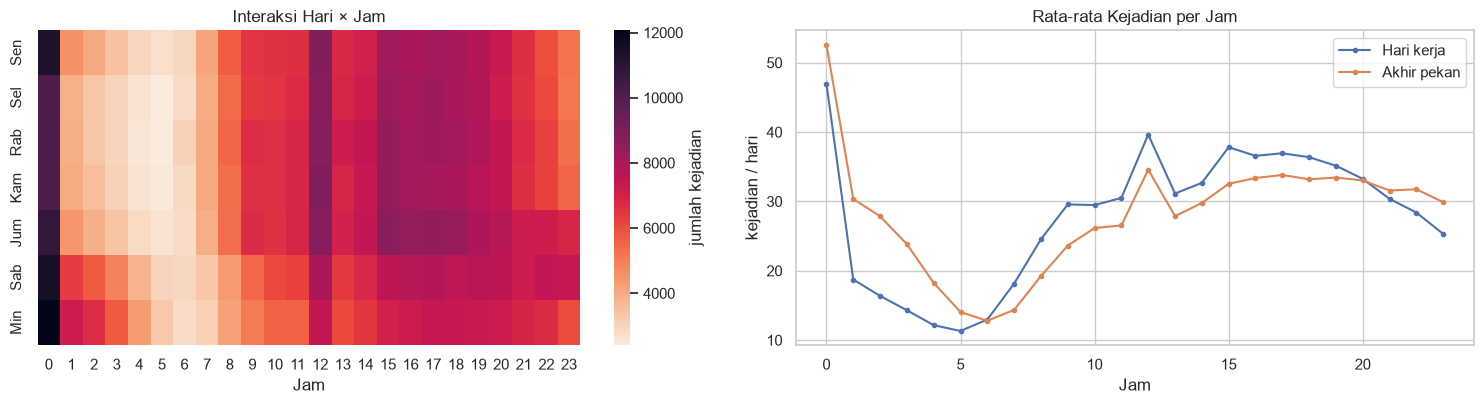

In [6]:
df["hour"] = df["Datetime"].dt.hour
df["dow"]  = df["Datetime"].dt.dayofweek     # 0 = Senin ... 6 = Minggu

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))

# (a) Heatmap hari x jam -> membuktikan ada interaksi, bukan efek terpisah
dow_hour = df.groupby(["dow", "hour"]).size().unstack("hour")
sns.heatmap(dow_hour, cmap="rocket_r", ax=axes[0],
            yticklabels=["Sen","Sel","Rab","Kam","Jum","Sab","Min"],
            cbar_kws={"label": "jumlah kejadian"})
axes[0].set_title("Interaksi Hari × Jam"); axes[0].set_xlabel("Jam"); axes[0].set_ylabel("")

# (b) Profil jam: hari kerja vs akhir pekan (dinormalisasi per hari agar adil)
is_wknd = df["dow"] >= 5
n_days = df.groupby(is_wknd)["Datetime"].apply(lambda s: s.dt.normalize().nunique())
hourly = df.groupby([is_wknd, "hour"]).size().unstack(0).div(n_days, axis=1)
axes[1].plot(hourly.index, hourly[False], marker="o", ms=3, label="Hari kerja")
axes[1].plot(hourly.index, hourly[True],  marker="o", ms=3, label="Akhir pekan")
axes[1].set_title("Rata-rata Kejadian per Jam"); axes[1].set_xlabel("Jam")
axes[1].set_ylabel("kejadian / hari"); axes[1].legend()

plt.tight_layout(); plt.show()

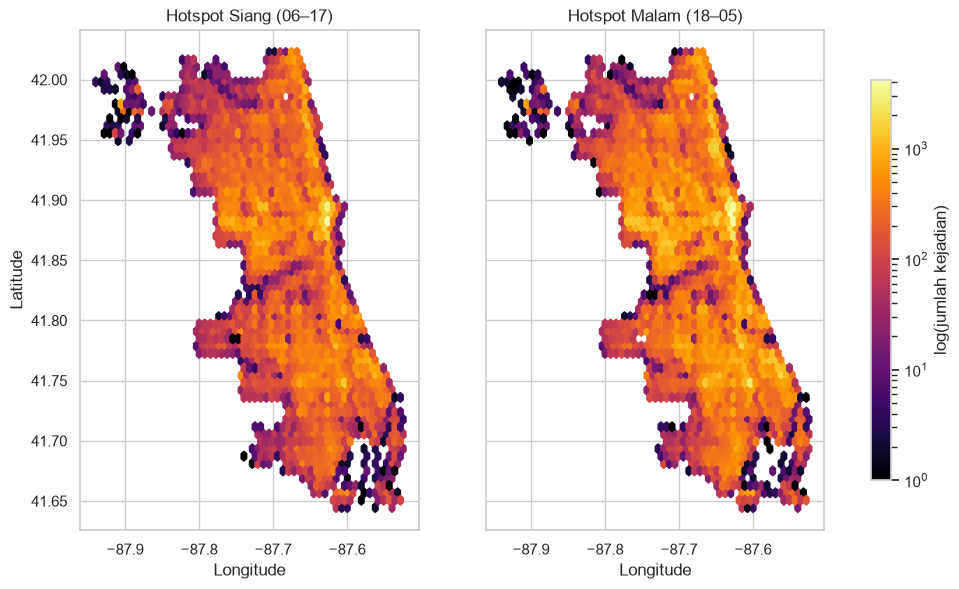

In [7]:
# Apakah lokasi hotspot bergeser antara siang dan malam?
is_day = df["hour"].between(6, 17)
extent = [df["Longitude"].min(), df["Longitude"].max(),
          df["Latitude"].min(),  df["Latitude"].max()]

fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), sharey=True)
for ax, mask, judul in [(axes[0], is_day, "Siang (06-17)"), (axes[1], ~is_day, "Malam (18-05)")]:
    part = df[mask]
    hb = ax.hexbin(part["Longitude"], part["Latitude"], gridsize=55,
                   cmap="inferno", mincnt=1, bins="log", extent=extent)
    ax.set_title(f"Hotspot {judul}"); ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(hb, ax=axes, label="log(jumlah kejadian)", shrink=0.8)
plt.show()

**Kesimpulan EDA yang menentukan desain.** Heatmap hari × jam memperlihatkan kombinasi
tertentu (Jumat-Sabtu larut malam) lebih "panas" daripada yang bisa dijelaskan efek hari
atau efek jam secara terpisah - artinya ada **interaksi nyata**. Profil hari kerja vs
akhir pekan juga berbeda bentuk, bukan sekadar berbeda tinggi.

Peta hotspot siang vs malam menunjukkan koridor rawan utama bertahan di lokasi yang sama,
tetapi **intensitas relatifnya bergeser**. Kesimpulannya: lokasi dan waktu tidak bisa
dipisahkan, sehingga unit analisis **(sel × hari × jam)** memang beralasan - bukan
kerumitan yang dibuat-buat.

## 5. Feature Engineering

### 5.1 Grid spasial

Koordinat lintang/bujur bersifat kontinu, sehingga dua kejadian di blok yang sama pun
hampir tidak pernah punya koordinat identik. Agar lokasi bisa **diagregasi dan
dibandingkan**, koordinat dibulatkan sehingga titik-titik berdekatan jatuh ke sel yang sama.

In [8]:
lat_r, lon_r, cell_id = F.latlon_to_grid(df["Latitude"], df["Longitude"])
df["lat_r"], df["lon_r"], df["cell_id"] = lat_r, lon_r, cell_id

# Bukti kuantitatif pilihan ukuran sel
rows = []
for deg, label in [(0.02, "0.02° (~2.2 km)"), (0.01, "0.01° (~1.1 km)  <- DIPAKAI"),
                   (0.005, "0.005° (~0.55 km)")]:
    gx = np.floor(df["Latitude"] / deg).astype(int)
    gy = np.floor(df["Longitude"] / deg).astype(int)
    n = (gx * 100_000 + gy).nunique()
    rows.append({"ukuran sel": label, "sel aktif": n,
                 "kejadian / sel": round(len(df) / n),
                 "kejadian / unit (168 slot)": round(len(df) / (n * 168), 1)})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nJumlah sel unik terpakai: {df['cell_id'].nunique():,}")

                 ukuran sel  sel aktif  kejadian / sel  kejadian / unit (168 slot)
            0.02° (~2.2 km)        212            4939                        29.4
0.01° (~1.1 km)  <- DIPAKAI        723            1448                         8.6
          0.005° (~0.55 km)       2565             408                         2.4

Jumlah sel unik terpakai: 732


**Keputusan: sel ~1,1 km (pembulatan 2 desimal).** Unit analisis kita adalah
*sel × hari × jam*, jadi setiap kali grid diperhalus, sinyal per unit terbagi makin tipis
- kepadatan lebih penting daripada resolusi di desain ini. Tabel di atas menunjukkan pada
0,005° rata-rata kejadian per unit jatuh ke ~2 (label akan didominasi noise), sedangkan
pada 0,02° satu sel mencampur beberapa lingkungan yang karakternya berbeda. 0,01° adalah
titik seimbangnya, dan kebetulan juga sebanding dengan jarak berjalan kaki yang relevan
untuk rekomendasi rute.

### 5.2 Fitur waktu - cyclical encoding

Waktu bersifat **siklikal**: jam 23:00 sebenarnya berdekatan dengan 00:00, tetapi sebagai
angka mentah selisihnya 23 (dianggap paling jauh). Setiap nilai siklikal dipetakan ke
lingkaran lewat sin & cos, sehingga kedekatan aslinya terjaga.

In [9]:
tf = F.build_time_features(df["Datetime"])
for k in ["is_weekend", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]:
    df[k] = tf[k]

# Bukti encoding-nya benar: 23:00 harus lebih dekat ke 00:00 daripada ke 12:00
p = lambda v: np.array(F.cyclical_encode(np.array([v]), 24)).ravel()
print(f"jarak 23:00 -> 00:00 = {np.linalg.norm(p(23)-p(0)):.3f}   (harus KECIL)")
print(f"jarak 00:00 -> 12:00 = {np.linalg.norm(p(0)-p(12)):.3f}   (harus BESAR)")

jarak 23:00 -> 00:00 = 0.261   (harus KECIL)
jarak 00:00 -> 12:00 = 2.000   (harus BESAR)


**Yang sengaja TIDAK dipakai:** `month`. Agar bisa jadi fitur, bulan harus ikut menjadi
dimensi unit analisis - akibatnya jumlah baris membengkak 12× dan kepadatan sinyal per
unit hancur. Efek musiman tidak hilang sepenuhnya: kejadian terbaru berbobot jauh lebih
besar lewat temporal decay, jadi musim yang sedang berjalan tetap "terasa" di label.

**`mean_severity` per unit juga tidak dipakai** sebagai fitur, karena hampir sirkular -
label Risk Score memang dibangun dari severity. Fitur yang bahannya sama persis dengan
label membuat model di CP2 "menebak resep sendiri", bukan belajar pola.

## 6. Pseudo-Labeling: Membentuk Risk Score

Dataset kejahatan **tidak punya kolom "Risk Score"** - tidak ada *ground truth*.
Pseudo-labeling membentuk label target dari **domain knowledge**, bertahap:

$$\text{severity} \;\xrightarrow{\;\times\, w_{\text{waktu}}\;} \text{event value}
\;\xrightarrow{\;\text{agregasi spasial}\;} \text{risk raw}
\;\xrightarrow{\;\text{normalisasi}\;} \text{Risk Score } 0\text{-}100$$

### 6.1 Severity - keparahan per kejadian

Skala 1-100 dijangkarkan pada **hierarki dampak terhadap manusia**, semangatnya sama
dengan *crime harm index* di literatur keamanan publik: kejahatan terhadap nyawa & tubuh
selalu di atas kejahatan properti, dan kehadiran senjata atau kerentanan korban menaikkan
keparahan.

| Pita | Rentang | Contoh |
| :-- | :-- | :-- |
| Nyawa | 90-100 | pembunuhan, kekerasan seksual bersenjata |
| Kekerasan bersenjata | 70-89 | perampokan bersenjata api, penganiayaan berat |
| Kekerasan tanpa senjata | 45-69 | battery/assault simple, perampokan tanpa senjata |
| Properti + interaksi korban | 30-44 | pembobolan rumah, pencurian dari orang |
| Properti tanpa interaksi | 10-29 | pencurian ringan, perusakan properti |
| Ketertiban umum | 1-9 | trespass, judi, pelanggaran miras |

Diterapkan **berjenjang 3 lapis** - anchor eksplisit, lalu base per tipe + modifier kata
kunci dari `Description`, lalu default. Desain berjenjang ini menghindari satu nilai
default yang meratakan mayoritas data.

In [10]:
df["severity"]  = F.compute_severity_series(df["primary_type_canon"], df["desc_canon"])
df["sev_layer"] = F.severity_layer(df["primary_type_canon"], df["desc_canon"])

print("Cakupan tiap lapis (% baris):")
print(df["sev_layer"].value_counts(normalize=True).mul(100).round(1).to_string())

print("\nApakah skala kita cocok dengan 5 contoh di dokumen soal?")
contoh = [("CRIMINAL SEXUAL ASSAULT", "AGGRAVATED: HANDGUN", 95),
          ("ROBBERY", "ARMED: HANDGUN", 82), ("BATTERY", "SIMPLE", 50),
          ("THEFT", "FROM PERSON", 38), ("CRIMINAL DAMAGE", "TO VEHICLE", 12)]
print(pd.DataFrame([{"Primary Type": p, "Description": d,
                     "severity kita": F.compute_severity(p, d), "contoh soal": e}
                    for p, d, e in contoh]).to_string(index=False))

Cakupan tiap lapis (% baris):
sev_layer
1-anchor           71.6
2-base+modifier    28.4

Apakah skala kita cocok dengan 5 contoh di dokumen soal?
           Primary Type         Description  severity kita  contoh soal
CRIMINAL SEXUAL ASSAULT AGGRAVATED: HANDGUN           95.0           95
                ROBBERY      ARMED: HANDGUN           82.0           82
                BATTERY              SIMPLE           50.0           50
                  THEFT         FROM PERSON           38.0           38
        CRIMINAL DAMAGE          TO VEHICLE           12.0           12


10 kombinasi terbanyak:
 primary_type_canon              desc_canon     n  severity
            BATTERY DOMESTIC BATTERY SIMPLE 82150      55.0
              THEFT          $500 AND UNDER 75255      20.0
              THEFT               OVER $500 75143      28.0
MOTOR VEHICLE THEFT              AUTOMOBILE 69913      35.0
    CRIMINAL DAMAGE              TO VEHICLE 64038      12.0
            BATTERY                  SIMPLE 63457      50.0
            ASSAULT                  SIMPLE 60545      45.0
    CRIMINAL DAMAGE             TO PROPERTY 49741      15.0
              THEFT            RETAIL THEFT 48605      18.0
              THEFT           FROM BUILDING 21084      22.0


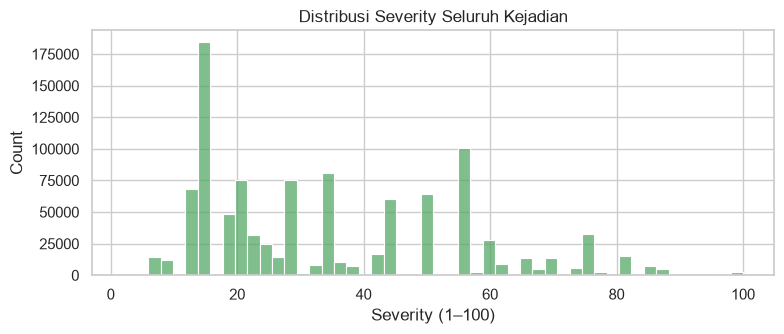

In [11]:
# Diagnostik: 10 kombinasi terbanyak + distribusi severity
komb = (df.groupby(["primary_type_canon", "desc_canon"], as_index=False)
          .agg(n=("ID", "size"), severity=("severity", "first"))
          .sort_values("n", ascending=False).head(10))
print("10 kombinasi terbanyak:")
print(komb.to_string(index=False))

plt.figure(figsize=(8, 3.5))
sns.histplot(df["severity"], bins=50, color="#55A868")
plt.title("Distribusi Severity Seluruh Kejadian"); plt.xlabel("Severity (1-100)")
plt.tight_layout(); plt.show()

**Justifikasi cakupan.** ~72% baris mendapat skor dari anchor eksplisit yang ditulis
tangan dan bisa diaudit satu per satu; sisanya jatuh ke lapis 2 yang sudah dikalibrasi di
sekitar nilai anchor. Tidak ada baris yang jatuh ke default global - artinya seluruh jenis
kejahatan di data sudah punya skor dasar yang disengaja, bukan angka asal.

Desain ini juga **tahan salah ketik**: kalau sebuah string anchor tidak persis sama dengan
di data, kombinasi itu tidak error - ia turun mulus ke lapis 2.

### 6.2 Temporal decay - kebaruan

Apakah kejahatan 3 tahun lalu perlu berkontribusi sebesar kejahatan kemarin? Tidak -
relevansi memudar seiring waktu. Bobotnya:

$$w_{\text{waktu}} = 0{,}5^{\,\Delta t / H}, \qquad H = \text{half-life}$$

Bentuk eksponensial dipilih (bukan linear) karena **tidak punya titik mati**: kejadian
paling lama tetap berbobot kecil-tapi-positif, bukan tiba-tiba nol di batas yang arbitrer.
Ini penting untuk skenario "kejahatan 2 tahun lalu" di uji akal sehat nanti.

In [12]:
REFERENCE_DATE = df["Datetime"].max()
df["age_days"] = (REFERENCE_DATE - df["Datetime"]).dt.total_seconds() / 86400
print(f"Tanggal referensi ('sekarang' menurut data): {REFERENCE_DATE}")

# Perbandingan beberapa half-life: bobot pada umur kunci + asal 'massa' label
umur = [(1, "kemarin"), (30, "1 bulan"), (180, "6 bulan"),
        (365, "1 tahun"), (730, "2 tahun"), (1460, "4 tahun")]
tab = {lbl: [round(float(F.temporal_weight(d, H)), 3) for d, lbl in umur]
       for H in [180, 365, 730] for lbl in [f"H={H}d"]}
print("\nBobot pada umur kejadian:")
print(pd.DataFrame(tab, index=[l for _, l in umur]).to_string())

print("\nKontribusi bobot per tahun (%):")
for H in [180, 365, 730]:
    w = F.temporal_weight(df["age_days"].to_numpy(), H)
    k = pd.Series(w).groupby(df["Datetime"].dt.year.to_numpy()).sum()
    print(f"  H={H:4d}d : " + ", ".join(f"{y}={v:.1f}%" for y, v in (k/k.sum()*100).round(1).items()))

Tanggal referensi ('sekarang' menurut data): 2026-04-11 00:00:00

Bobot pada umur kejadian:
         H=180d  H=365d  H=730d
kemarin   0.996   0.998   0.999
1 bulan   0.891   0.945   0.972
6 bulan   0.500   0.710   0.843
1 tahun   0.245   0.500   0.707
2 tahun   0.060   0.250   0.500
4 tahun   0.004   0.062   0.250

Kontribusi bobot per tahun (%):
  H= 180d : 2022=0.8%, 2023=3.5%, 2024=14.0%, 2025=52.4%, 2026=29.3%
  H= 365d : 2022=5.4%, 2023=11.9%, 2024=23.5%, 2025=43.0%, 2026=16.1%


  H= 730d : 2022=11.9%, 2023=18.6%, 2024=25.9%, 2025=33.5%, 2026=10.2%


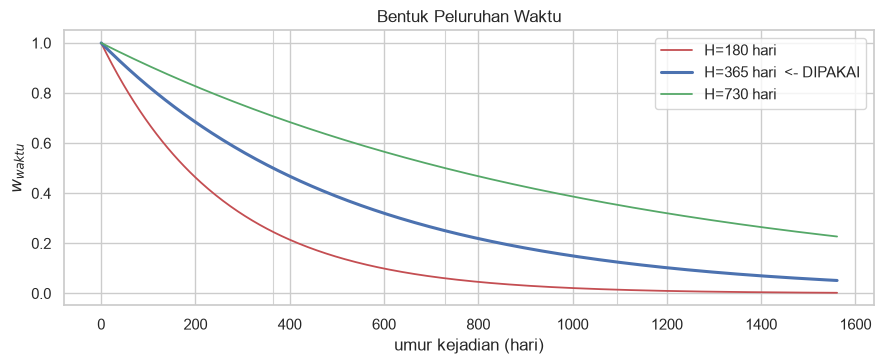

Half-life terpakai: 365 hari


In [13]:
plt.figure(figsize=(9, 3.8))
ages = np.linspace(0, df["age_days"].max(), 400)
for H, c in [(180, "#C44E52"), (365, "#4C72B0"), (730, "#55A868")]:
    plt.plot(ages, F.temporal_weight(ages, H), color=c, lw=2.2 if H == 365 else 1.3,
             label=f"H={H} hari" + ("  <- DIPAKAI" if H == 365 else ""))
for th in (365, 730, 1095):
    plt.axvline(th, color="lightgray", lw=0.8, zorder=0)
plt.title("Bentuk Peluruhan Waktu"); plt.xlabel("umur kejadian (hari)")
plt.ylabel(r"$w_{waktu}$"); plt.legend(); plt.tight_layout(); plt.show()

df["w_time"] = F.temporal_weight(df["age_days"].to_numpy(), F.HALF_LIFE_DAYS)
df["event_value"] = df["severity"] * df["w_time"]
print(f"Half-life terpakai: {F.HALF_LIFE_DAYS:.0f} hari")

**Keputusan: half-life 365 hari.** Angka ini **bukan pilihan bebas** - ia dijepit dari dua
arah oleh uji akal sehat di Bagian 7. Batas bawah: pada H=180 hari (versi awal kami),
kejahatan 2 tahun lalu hanya berbobot 6%, praktis nol, padahal dokumen soal mengharapkan
skenario itu bernilai *sedang*. Batas atas: pada H=730 hari decay hampir kehilangan
fungsinya - kejadian 2 tahun lalu masih berbobot 50%, sehingga pola lama ikut menyetir
label yang seharusnya menggambarkan kondisi terkini.

H=365 juga punya arti yang enak dijelaskan: **satu siklus musim penuh**. Label tidak
condong ke musim yang kebetulan sedang berjalan saat snapshot diambil, padahal label akan
dipakai sepanjang tahun.

### 6.3 Agregasi spasial - kedekatan

Risiko sebuah titik tidak hanya ditentukan oleh kejahatan tepat di sel itu; area
sekitarnya juga relevan. Bobot tetangga memakai kernel Gaussian atas **jarak haversine
sesungguhnya**:

$$w_{\text{jarak}} = \exp\!\left(-\frac{d^2}{2\sigma^2}\right)$$

Jarak bumi sungguhan dipakai - bukan selisih indeks grid - karena grid derajat bersifat
**anisotropik** di Chicago: 0,01° lintang ≈ 1,11 km, tapi 0,01° bujur hanya ≈ 0,83 km.
Memperlakukan keduanya sama akan membuat pengaruh ke arah timur-barat melebar keliru.

In [14]:
df["is_violent"] = df["primary_type_canon"].isin(F.VIOLENT_TYPES)

unit = (df.groupby(["cell_id", "lat_r", "lon_r", "dow", "hour"], as_index=False)
          .agg(base_value    = ("event_value", "sum"),
               crime_count   = ("ID", "size"),
               violent_share = ("is_violent", "mean"),
               arrest_rate   = ("Arrest", "mean")))
print(f"Unit teramati : {len(unit):,} baris")
print(f"Sel unik      : {unit['cell_id'].nunique()}")
print(f"Slot penuh    : {unit['cell_id'].nunique()} sel x 168 slot = {unit['cell_id'].nunique()*168:,}")
unit.head(3)

Unit teramati : 99,241 baris
Sel unik      : 732
Slot penuh    : 732 sel x 168 slot = 122,976


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count,violent_share,arrest_rate
0,41.64_-87.54,41.64,-87.54,0,8,17.378569,1,0.0,0.0
1,41.64_-87.54,41.64,-87.54,0,18,1.043203,1,0.0,0.0
2,41.64_-87.54,41.64,-87.54,1,15,9.019055,1,0.0,0.0


In [15]:
# --- Matriks bobot antar-sel: dihitung SEKALI (jarak tidak bergantung waktu) ---
cells = (unit[["cell_id", "lat_r", "lon_r"]].drop_duplicates("cell_id")
         .sort_values("cell_id").reset_index(drop=True))
n_cells = len(cells)
cell_idx = {c: i for i, c in enumerate(cells["cell_id"])}

W = F.build_spatial_weight_matrix(cells["lat_r"], cells["lon_r"])
print(f"Matriks bobot : {n_cells} x {n_cells} | rata-rata tetangga efektif: {W.getnnz()/n_cells:.1f}")

# --- Susun matriks (sel x 168 slot); slot tanpa kejadian = 0, memang 0 kejadian ---
slot = unit["dow"].to_numpy() * 24 + unit["hour"].to_numpy()
ci   = unit["cell_id"].map(cell_idx).to_numpy()

M = np.zeros((n_cells, 168)); M[ci, slot] = unit["base_value"].to_numpy()
Cc= np.zeros((n_cells, 168)); Cc[ci, slot] = unit["crime_count"].to_numpy()
Vv= np.zeros((n_cells, 168)); Vv[ci, slot] = unit["violent_share"].to_numpy()
Aa= np.zeros((n_cells, 168)); Aa[ci, slot] = unit["arrest_rate"].to_numpy()

# Smoothing seluruh 168 slot sekaligus lewat satu perkalian matriks
S = W @ M
print(f"risk_raw range: {S.min():.3f} .. {S.max():.2f}")

Matriks bobot : 732 x 732 | rata-rata tetangga efektif: 26.1
risk_raw range: 0.000 .. 1596.78


**Tiga keputusan dalam satu paket:**

**(a) Weighted MEAN, bukan weighted sum.** Baris matriks bobot dinormalisasi sehingga
berjumlah 1. Ini disengaja: `base_value` tiap sel *sudah* memuat volume kejadian, jadi
kernel-sum akan menghitung volume dua kali - pusat kawasan padat menggelembung, sementara
sel di tepi kota atau tepi danau tertekan hanya karena tetangganya lebih sedikit.
Weighted mean berarti "level risiko lokal yang diharapkan", dan skalanya tetap sebanding
dengan `base_value`.

**(b) σ = 0,7 km.** Ini **revisi** dari nilai awal kami (1,0 km). Pada σ = 1,0 km, sebuah
kejahatan di sel tetangga (1,11 km) bernilai 54% dari kejahatan di sel sendiri - terlalu
tinggi, dan membuat peta risiko terlalu kabur. Pada σ = 0,7 km bobotnya turun ke 28%,
sesuai harapan dokumen soal bahwa skenario "kejahatan di grid tetangga" bernilai
*rendah sampai sedang*. Nilai ini masih terwakili baik oleh grid: jarak antar-sel terdekat
(0,83 dan 1,11 km) menghasilkan bobot yang jelas berbeda (0,50 dan 0,28).

**(c) Grid lengkap, bukan hanya slot yang pernah ada kejadian.** Kalau dataset final hanya
memuat slot ber-kejadian, model di CP2 tidak pernah melihat contoh "tempat-waktu aman" -
padahal slot kosong di sebelah hotspot berisiko > 0, sedangkan slot kosong di area sepi
berisiko ≈ 0. Dua informasi itu justru berharga untuk rekomendasi rute.

In [16]:
# Fitur konteks tetangga: rata-rata crime_count 8 sel sekeliling pada slot waktu yang sama
gx, gy = F.grid_to_index(cells["lat_r"], cells["lon_r"])
pos = {(a, b): i for i, (a, b) in enumerate(zip(gx, gy))}
offsets = [(dx, dy) for dx in (-1, 0, 1) for dy in (-1, 0, 1) if (dx, dy) != (0, 0)]

NB = np.zeros((n_cells, 168))
for dx, dy in offsets:
    src = np.array([pos.get((a + dx, b + dy), -1) for a, b in zip(gx, gy)])
    ok = src >= 0
    NB[ok] += Cc[src[ok]]
NB /= len(offsets)

# Bentangkan matriks menjadi tabel panjang: satu baris = satu (sel, hari, jam)
grid = pd.DataFrame({
    "cell_id": np.repeat(cells["cell_id"].to_numpy(), 168),
    "lat_r":   np.repeat(cells["lat_r"].to_numpy(), 168),
    "lon_r":   np.repeat(cells["lon_r"].to_numpy(), 168),
    "dow":     np.tile(np.repeat(np.arange(7), 24), n_cells),
    "hour":    np.tile(np.tile(np.arange(24), 7), n_cells),
    "base_value": M.ravel(), "risk_raw": S.ravel(),
    "crime_count": Cc.ravel(), "violent_share": Vv.ravel(),
    "arrest_rate": Aa.ravel(), "neighbor_count_mean": NB.ravel(),
})
grid = grid.merge(df.groupby("cell_id").size().rename("cell_total_count"), on="cell_id")

grid["is_weekend"] = (grid["dow"] >= 5).astype(int)
grid["hour_sin"], grid["hour_cos"] = F.cyclical_encode(grid["hour"], 24)
grid["dow_sin"],  grid["dow_cos"]  = F.cyclical_encode(grid["dow"], 7)

n_kosong = int((grid["crime_count"] == 0).sum())
print(f"Grid lengkap: {len(grid):,} baris ({n_kosong:,} slot tanpa kejadian kini ikut terdefinisi)")

Grid lengkap: 122,976 baris (23,735 slot tanpa kejadian kini ikut terdefinisi)


### 6.4 Normalisasi ke skala 0-100

`risk_raw` sangat *skewed*: mayoritas kecil, segelintir sangat besar. Normalisasinya
memakai **dua jangkar eksplisit**:

$$\text{score} = 100 \times \left(\frac{\min(\text{risk raw},\ c)}{c}\right)^{\alpha},
\qquad c = \text{persentil-99}$$

- `risk_raw = 0` → skor **0** (tidak ada kejahatan sama sekali)
- `risk_raw ≥ c` → skor **100** (level persentil-99 ke atas)

Pemotongan di persentil-99 membuat "skor 100" berarti *level persentil-99 ke atas*, bukan
level satu slot paling ekstrem - sehingga satu outlier tidak mendikte seluruh skala.

Yang tersisa adalah memilih **α**, yang mengatur seberapa terangkat bagian tengah
distribusi. Kandidatnya dibandingkan langsung di bawah.

Jangkar 'skor 100' (persentil 99% dari risk_raw) = 384.17

                    kandidat  median   Q1   Q3  % skor <25  % skor >75
           A. linear (a=1.0)    17.7  6.3 34.9        62.3         3.4
 B. AKAR (a=0.5)  <- DIPAKAI    42.1 25.0 59.0        25.0         9.3
                   C. a=0.35    54.5 37.9 69.1        10.4        16.9
D. log1p+minmax (versi awal)    71.1 54.1 82.4         5.8        41.8


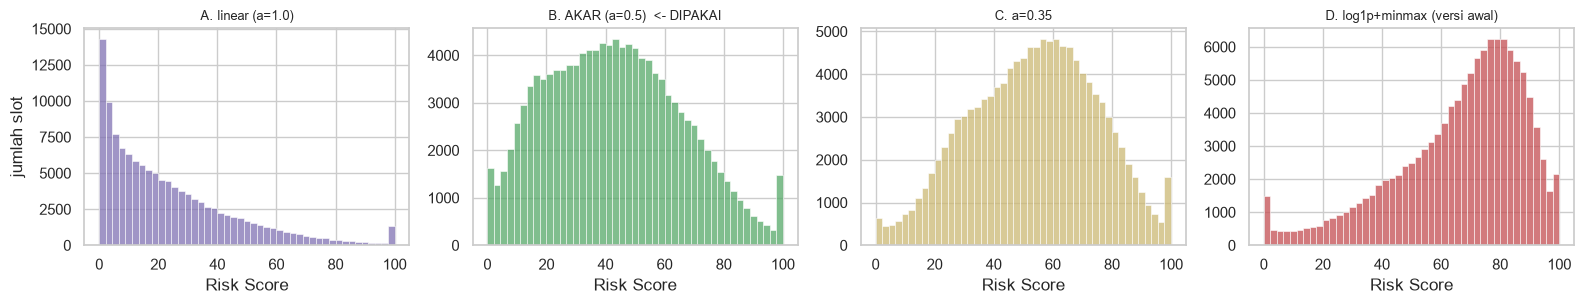

In [17]:
clip_value = F.fit_score_scaler(grid["risk_raw"])
print(f"Jangkar 'skor 100' (persentil {F.CLIP_PERCENTILE:.0%} dari risk_raw) = {clip_value:.2f}\n")

kandidat = {
    "A. linear (a=1.0)":            F.normalize_risk_score(grid["risk_raw"], clip_value, 1.0),
    "B. AKAR (a=0.5)  <- DIPAKAI":  F.normalize_risk_score(grid["risk_raw"], clip_value, 0.5),
    "C. a=0.35":                    F.normalize_risk_score(grid["risk_raw"], clip_value, 0.35),
    "D. log1p+minmax (versi awal)": 100*np.log1p(np.clip(grid["risk_raw"],0,clip_value))/np.log1p(clip_value),
}
ring = pd.DataFrame([{ "kandidat": k, "median": np.median(v), "Q1": np.quantile(v,.25),
                       "Q3": np.quantile(v,.75), "% skor <25": (np.asarray(v)<25).mean()*100,
                       "% skor >75": (np.asarray(v)>75).mean()*100}
                     for k, v in kandidat.items()])
print(ring.round(1).to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, (nama, val), c in zip(axes, kandidat.items(), ["#8172B3","#55A868","#CCB974","#C44E52"]):
    sns.histplot(val, bins=45, ax=ax, color=c)
    ax.set_title(nama, fontsize=9); ax.set_xlabel("Risk Score"); ax.set_ylabel("")
axes[0].set_ylabel("jumlah slot")
plt.tight_layout(); plt.show()

**Keputusan: α = 0,5 (akar kuadrat).** Ini **perbaikan paling penting** atas kedua versi
awal kami, yang sama-sama memakai `log1p` + min-max.

Masalahnya terlihat jelas di tabel: dengan `log1p`, **median skor 71 dan 42% slot bernilai
di atas 75**. Artinya jalan biasa-biasa saja di Chicago terbaca "berisiko tinggi" - untuk
aplikasi rekomendasi rute, tampilannya jadi tidak berguna karena hampir semua tampak
berbahaya, dan skenario "tidak ada kejahatan → 0" praktis tidak pernah tercapai. Penyebabnya
matematis: `log1p` mengompres ujung atas sangat kuat, sehingga nilai tengah ikut terangkat.

Di ujung sebaliknya, α = 1,0 (linear) membuat 62% slot bernilai di bawah 25 - daya bedanya
hilang justru di wilayah yang paling banyak datanya. α = 0,5 duduk di tengah: median ~42,
kuartil 25-59, dan hanya ~9% slot di atas 75 sehingga skor tinggi kembali bermakna.

count    122976.00
mean         43.03
std          22.75
min           0.00
25%          25.03
50%          42.06
75%          59.04
max         100.00


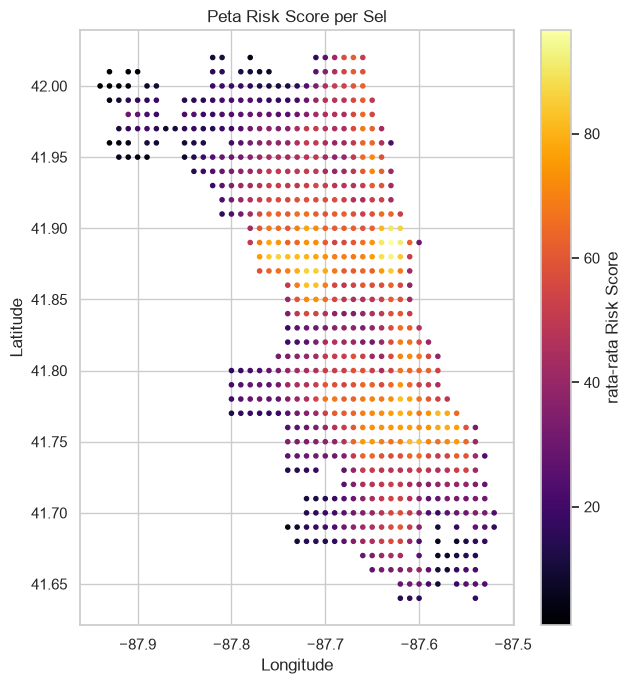

In [18]:
grid["risk_score"] = F.normalize_risk_score(grid["risk_raw"], clip_value, F.SCORE_EXPONENT)
print(grid["risk_score"].describe().round(2).to_string())

# Peta risiko rata-rata per sel -- harus sejalan dengan hotspot di EDA
cell_risk = grid.groupby(["lat_r", "lon_r"], as_index=False)["risk_score"].mean()
plt.figure(figsize=(6.5, 7))
sc = plt.scatter(cell_risk["lon_r"], cell_risk["lat_r"], c=cell_risk["risk_score"],
                 cmap="inferno", s=9)
plt.colorbar(sc, label="rata-rata Risk Score")
plt.title("Peta Risk Score per Sel"); plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

## 7. Uji Akal Sehat - Empat Skenario Dokumen Soal

Dokumen soal memberi empat skenario beserta perilaku yang diharapkan. Ini pembanding
paling objektif yang kita punya, jadi diuji secara eksplisit - bukan diklaim.

| # | Skenario | Harapan |
| :-- | :-- | :-- |
| 1 | kejahatan kemarin, grid sama | skor sangat tinggi |
| 2 | kejahatan 2 tahun lalu, grid sama | sedang |
| 3 | kejahatan kemarin, grid tetangga (~1 km) | rendah sampai sedang |
| 4 | tidak ada kejahatan dalam radius | 0 |

**Cara membacanya.** Skenario-skenario ini berbicara tentang **kontribusi satu kejadian**,
sedangkan label kita adalah agregat ribuan kejadian selama 4 tahun. Jadi yang diuji adalah
**kontribusi relatif** satu kejadian pada masing-masing skenario, dengan skenario 1
ditetapkan sebagai 100%. Yang harus benar adalah *urutan* dan *besaran relatifnya*.

In [19]:
GRID_STEP_KM = 1.11    # jarak sel bertetangga pada 0.01 derajat lintang

def skenario_relatif(H, sigma):
    acuan = F.temporal_weight(1.0, H) * F.spatial_weight(0.0, sigma)
    s = {
        "1. kemarin, grid sama":      F.temporal_weight(1.0,   H) * F.spatial_weight(0.0, sigma),
        "2. 2 tahun lalu, grid sama": F.temporal_weight(730.0, H) * F.spatial_weight(0.0, sigma),
        "3. kemarin, grid tetangga":  F.temporal_weight(1.0,   H) * F.spatial_weight(GRID_STEP_KM, sigma),
        "4. tidak ada kejahatan":     0.0,
    }
    return {k: 100 * v / acuan for k, v in s.items()}

hasil = skenario_relatif(F.HALF_LIFE_DAYS, F.SIGMA_KM)
harapan = ["sangat tinggi", "sedang", "rendah sampai sedang", "0"]
print(f"Parameter terpakai: H={F.HALF_LIFE_DAYS:.0f} hari, sigma={F.SIGMA_KM} km\n")
print(pd.DataFrame({"kontribusi relatif (%)": [round(v,1) for v in hasil.values()],
                    "harapan dokumen soal": harapan}, index=hasil.keys()).to_string())

Parameter terpakai: H=365 hari, sigma=0.7 km

                            kontribusi relatif (%)  harapan dokumen soal
1. kemarin, grid sama                        100.0         sangat tinggi
2. 2 tahun lalu, grid sama                    25.0                sedang
3. kemarin, grid tetangga                     28.4  rendah sampai sedang
4. tidak ada kejahatan                         0.0                     0


In [20]:
# Kenapa parameter ini yang dipilih: perbandingan lintas kombinasi (H, sigma)
baris = []
for H in [180, 365, 730]:
    for sg in [0.7, 1.0]:
        r = skenario_relatif(H, sg)
        baris.append({"H (hari)": H, "sigma (km)": sg,
                      "S1 kemarin": round(r["1. kemarin, grid sama"], 1),
                      "S2 2 tahun": round(r["2. 2 tahun lalu, grid sama"], 1),
                      "S3 tetangga": round(r["3. kemarin, grid tetangga"], 1),
                      "dipakai": "<--" if (H == F.HALF_LIFE_DAYS and sg == F.SIGMA_KM) else ""})
print("Perbandingan kombinasi parameter (kontribusi relatif, %):")
print(pd.DataFrame(baris).to_string(index=False))

Perbandingan kombinasi parameter (kontribusi relatif, %):
 H (hari)  sigma (km)  S1 kemarin  S2 2 tahun  S3 tetangga dipakai
      180         0.7       100.0         6.0         28.4        
      180         1.0       100.0         6.0         54.0        
      365         0.7       100.0        25.0         28.4     <--
      365         1.0       100.0        25.0         54.0        
      730         0.7       100.0        50.0         28.4        
      730         1.0       100.0        50.0         54.0        


**Hasil dan penafsiran jujur.**

Skenario 1 dan 4 terpenuhi telak: kejadian kemarin di sel yang sama adalah acuan tertinggi
(100%), dan tanpa kejahatan sama sekali skornya benar-benar **0** - bukan mendekati nol,
karena `risk_raw = 0` dipetakan persis ke 0 oleh dua-jangkar di Bagian 6.4.

Skenario 2 dan 3 mendarat di **25%** dan **28%** - keduanya di pita rendah-sedang, sesuai
harapan dokumen. Tabel perbandingan menunjukkan kenapa parameter awal kami tidak memadai:
pada H=180 hari, skenario 2 hanya bernilai 6% (praktis nol, padahal diharapkan *sedang*),
dan pada σ=1,0 km skenario 3 melonjak ke 54% (terlalu tinggi untuk sesuatu yang diharapkan
*rendah sampai sedang*).

Satu catatan yang kami sampaikan apa adanya: dokumen soal menyiratkan skenario 2 sedikit
**di atas** skenario 3, sedangkan pada parameter kami keduanya praktis setara (25% vs 28%).
Untuk membuat skenario 2 benar-benar melampaui skenario 3 dibutuhkan half-life ≈ 2 tahun,
tetapi pada titik itu peluruhan waktu kehilangan fungsinya - kejadian lama akan menyetir
label yang seharusnya menggambarkan kondisi terkini. Kami memilih menjaga fungsi decay dan
menerima kedua skenario berada di pita yang sama, karena tabel dokumen bersifat kualitatif.

Slot tanpa kejahatan & tanpa tetangga berkejahatan : n=2,620
   median Risk Score = 1.6
Slot 1% terpadat : median Risk Score = 100.0

Korelasi Spearman risk_score vs crime_count = 0.871


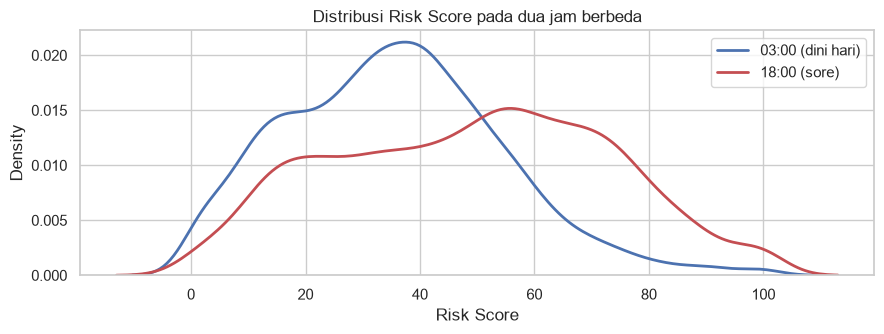

In [21]:
# Uji tambahan pada data nyata: apakah slot benar-benar sepi memang berskor rendah?
sepi  = grid[(grid["crime_count"] == 0) & (grid["neighbor_count_mean"] == 0)]
ramai = grid.nlargest(int(0.01 * len(grid)), "crime_count")

print(f"Slot tanpa kejahatan & tanpa tetangga berkejahatan : n={len(sepi):,}")
print(f"   median Risk Score = {sepi['risk_score'].median():.1f}" if len(sepi) else "   (tidak ada)")
print(f"Slot 1% terpadat : median Risk Score = {ramai['risk_score'].median():.1f}")
print(f"\nKorelasi Spearman risk_score vs crime_count = "
      f"{grid[['risk_score','crime_count']].corr(method='spearman').iloc[0,1]:.3f}")

plt.figure(figsize=(9, 3.5))
for h, lbl, c in [(3, "03:00 (dini hari)", "#4C72B0"), (18, "18:00 (sore)", "#C44E52")]:
    sns.kdeplot(grid[grid["hour"] == h]["risk_score"], label=lbl, color=c, lw=2)
plt.title("Distribusi Risk Score pada dua jam berbeda"); plt.xlabel("Risk Score"); plt.legend()
plt.tight_layout(); plt.show()

## 8. Dataset Akhir

Kolom fitur dan kolom **pembentuk label** dipisahkan secara eksplisit. `base_value` dan
`risk_raw` adalah bahan mentah pembentuk `risk_score`, sehingga **tidak boleh** ikut
sebagai fitur model - memakainya berarti model menebak label dari bahannya sendiri
(kebocoran total). Pemisahan ini didefinisikan di `features.py` supaya tidak bergantung
pada kedisiplinan orang yang memakainya nanti.

In [22]:
print("Kolom fitur      :", F.FEATURE_COLUMNS)
print("Kolom label      :", F.TARGET_COLUMN)
print("DIKECUALIKAN     :", F.LABEL_INGREDIENT_COLUMNS, " <- bahan pembentuk label")

final_cols = ["cell_id"] + F.FEATURE_COLUMNS + [F.TARGET_COLUMN]
final = grid[["cell_id", "dow", "hour"] + [c for c in final_cols if c not in ("cell_id",)]]
final = final.loc[:, ~final.columns.duplicated()].copy()

print(f"\nShape dataset akhir: {final.shape}")
print(f"NaN                : {int(final.isna().sum().sum())}")
final.head()

Kolom fitur      : ['lat_r', 'lon_r', 'hour', 'dow', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'crime_count', 'violent_share', 'arrest_rate', 'cell_total_count', 'neighbor_count_mean']
Kolom label      : risk_score
DIKECUALIKAN     : ['base_value', 'risk_raw']  <- bahan pembentuk label

Shape dataset akhir: (122976, 16)
NaN                : 0


,cell_id,dow,hour,lat_r,lon_r,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,crime_count,violent_share,arrest_rate,cell_total_count,neighbor_count_mean,risk_score
0,41.64_-87.54,0,0,41.64,-87.54,0,0.000000,1.000000,0.0,1.0,0.0,0.0,0.0,4,2.375,29.360134
1,41.64_-87.54,0,1,41.64,-87.54,0,0.258819,0.965926,0.0,1.0,0.0,0.0,0.0,4,0.750,16.385697
2,41.64_-87.54,0,2,41.64,-87.54,0,0.500000,0.866025,0.0,1.0,0.0,0.0,0.0,4,2.250,28.120807
3,41.64_-87.54,0,3,41.64,-87.54,0,0.707107,0.707107,0.0,1.0,0.0,0.0,0.0,4,0.375,12.632075
4,41.64_-87.54,0,4,41.64,-87.54,0,0.866025,0.500000,0.0,1.0,0.0,0.0,0.0,4,0.375,13.203746


In [23]:
final.to_csv("features_labels.csv", index=False)
size_mb = os.path.getsize("features_labels.csv") / 1e6
print(f"Tersimpan: features_labels.csv  ({size_mb:.1f} MB, {len(final):,} baris)")

# Versi sampel untuk keperluan unggah bila ukuran penuh terlalu besar
sample = final.sample(n=min(5000, len(final)), random_state=42).sort_values(["cell_id","dow","hour"])
sample.to_csv("features_labels_sample.csv", index=False)
print(f"Tersimpan: features_labels_sample.csv ({os.path.getsize('features_labels_sample.csv')/1e6:.2f} MB, {len(sample):,} baris)")

# Parameter yang WAJIB dibekukan & ikut ke CP2 (jangan dihitung ulang saat serving)
import json
meta = {"reference_date": str(REFERENCE_DATE), "subset_start_year": SUBSET_START_YEAR,
        "grid_decimals": F.GRID_DECIMALS, "half_life_days": F.HALF_LIFE_DAYS,
        "sigma_km": F.SIGMA_KM, "cutoff_km": F.CUTOFF_KM,
        "clip_percentile": F.CLIP_PERCENTILE, "score_clip_value": float(clip_value),
        "score_exponent": F.SCORE_EXPONENT,
        "n_cells": int(n_cells), "n_rows": int(len(final)),
        "feature_columns": F.FEATURE_COLUMNS, "target": F.TARGET_COLUMN,
        "label_ingredient_columns": F.LABEL_INGREDIENT_COLUMNS}
with open("label_params.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Tersimpan: label_params.json  <- jangkar skor & parameter, dibekukan untuk CP2")

Tersimpan: features_labels.csv  (19.1 MB, 122,976 baris)
Tersimpan: features_labels_sample.csv (0.77 MB, 5,000 baris)
Tersimpan: label_params.json  <- jangkar skor & parameter, dibekukan untuk CP2


> **Kenapa `label_params.json` penting.** Nilai jangkar "skor 100" (persentil-99 dari
> `risk_raw`) harus **dibekukan** dan ikut dibawa ke CP2. Kalau tiap kali data baru datang
> label dinormalisasi ulang dengan jangkarnya sendiri, arti "skor 80" ikut bergeser diam-diam
> - perbandingan antar waktu jadi tidak sah, dan kenaikan level kejahatan yang sesungguhnya
> tidak akan pernah terlihat di label.

## 9. Disclaimer Etis & Limitasi

**Disclaimer.** Sistem ini menghasilkan **estimasi berbasis pola historis** kejahatan yang
*dilaporkan* di Chicago - **bukan prediksi kepastian** bahwa suatu kejadian akan terjadi.
Skor tinggi berarti "secara historis, area dan waktu ini lebih sering menjadi lokasi
kejahatan tercatat", bukan "Anda akan menjadi korban". Konteks Chicago juga **berbeda jauh
dengan Indonesia** - struktur kota, pola pelaporan, dan definisi hukum kejahatannya tidak
sama, sehingga angka ini tidak bisa dipindahkan begitu saja ke kota di Indonesia. Dataset
ini dipakai sebagai bahan latihan karena tersedia terbuka dan berlabel rapi.

Sistem semacam ini juga berisiko menimbulkan **umpan balik yang memperkuat bias**: area
yang lebih sering dipatroli menghasilkan lebih banyak laporan, yang menaikkan skor, yang
bisa mendorong lebih banyak perhatian ke area itu lagi. Karena itu skor sebaiknya dipakai
untuk **memberi informasi kepada pengguna**, bukan untuk menandai suatu lingkungan sebagai
"buruk", dan sebaiknya tidak ditampilkan dengan bahasa yang menstigma.

**Limitasi yang kami sadari:**

1. **Bias pelaporan.** Data adalah kejahatan yang *dilaporkan*; skor ikut mencerminkan pola
   pelaporan dan kehadiran polisi, bukan semata kejahatan aktual.
2. **Kualitas waktu & klasifikasi.** Dokumentasi resmi menyebut waktu kejadian kerap
   estimasi dan klasifikasi awal bisa direvisi - noise ini terwariskan ke fitur jam dan
   severity.
3. **Bobot severity adalah penilaian, bukan pengukuran.** Angkanya disusun dari hierarki
   dampak yang masuk akal dan dijangkarkan ke contoh dokumen soal, tapi tetap sebuah
   pilihan normatif yang bisa diperdebatkan.
4. **Label slot kosong adalah estimasi.** Pada grid lengkap, slot tanpa kejadian mendapat
   label hasil smoothing tetangga - perlu diingat saat mengevaluasi model di CP2.
5. **Kejahatan berlokasi administratif.** Sebagian tipe (mis. penipuan daring) mencatat
   alamat korban, bukan tempat bahaya fisik. Kontribusinya ke label sudah kecil karena
   severity-nya di pita bawah, tapi masih terhitung di `crime_count`.

## 10. Ringkasan Keputusan

| Komponen | Keputusan | Alasan singkat |
| :-- | :-- | :-- |
| Unit analisis | sel × hari × jam | risiko berubah menurut jam & hari (EDA §4); dibutuhkan rekomendasi rute malam |
| Subset | seluruh kota, 2022 - Apr 2026 | hindari anomali pandemi; terkunci dengan decay |
| Ukuran grid | 0,01° (~1,1 km) | seimbang antara resolusi & kepadatan sinyal |
| Fitur waktu | sin/cos jam & hari + is_weekend | jam 23 harus dekat dengan jam 0 |
| Severity | hybrid 3 lapis, skala 1-100 | ~72% dari anchor auditable; cocok 5/5 contoh soal |
| Temporal decay | eksponensial, **H = 365 hari** | direvisi dari 180 - uji akal sehat §7 |
| Agregasi spasial | Gaussian haversine, **σ = 0,7 km**, weighted mean | direvisi dari 1,0 km - uji akal sehat §7 |
| Normalisasi | dua jangkar, **α = 0,5** | direvisi dari `log1p` - median 71 → 42 |
| Cakupan | grid lengkap 732 × 168 | model perlu melihat contoh "tempat-waktu aman" |

**Tiga perbaikan** atas versi awal kami, semuanya didorong bukti di notebook ini:
half-life 180 → 365 hari, σ 1,0 → 0,7 km, dan normalisasi `log1p` → akar kuadrat berjangkar.
Ketiganya lahir dari uji akal sehat empat skenario di Bagian 7 - bagian yang sebelumnya
belum pernah kami uji secara eksplisit.

Hal-hal yang sengaja ditunda ke Checkpoint 2 tercatat di **`NOTES_CP2.md`**.